# J Lens Bias - Week 1 Assignment

## What features are we looking for?

The Jlens repo's examples and experiment files are designed to probe several different kinds of content. These are the feature families considered in this notebook:

| Feature family | Intuition-building example | What to inspect |
| --- | --- | --- |
| Factual and multi-hop knowledge | Country or entity -> answer | Does a bridge entity become readable before the final answer? |
| Compositional knowledge | Capital, language, currency, or season | Can an argument support different functions? |
| Latent concept holding | Think about a topic while writing another sentence | Does an unrelated concept appear in the readout? |
| Arithmetic and symbolic content | Evaluate a small expression while copying text | Does numerical content become readable? |
| Structural and visual interpretation | ASCII face | Do symbols evoke a semantic label such as `face` or `nose`? |
| Code and error recognition | Off-by-one Python function | Does the readout surface concepts such as `index` or `error`? |
| Safety-relevant salience | Dangerous-dose or crisis-like prompt | Which safety-related tokens become accessible, and under what context? |
| Introspection and verbal report | Asked to identify a possibly injected thought | Can a latent concept be reported, and how strongly? |
| Selectivity and interference | Language, line-count, capacity, and dual-task controls | Is a readout task-specific, or merely a generic association? |

These are readout categories, not claims that the model has human-like concepts or conscious thoughts. A Jacobian Lens measures what an activation is disposed to make the model say.

## Evidence standards

Keeping the following three claims separate:

- **Readout claim:** a token is highly ranked at a layer and position.
- **Behavioral claim:** the model's final output favors a token.
- **Causal claim:** changing an internal representation changes the output in a predicted way.


In [1]:
# Imports used throughout the notebook.
from pathlib import Path
import json
import time

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import transformers

sns.set_theme(style="whitegrid", context="notebook")
print("Imports complete.")

Imports complete.


## 1. Install and load the Jacobian Lens repository

This cell is safe to rerun. It clones the repository only when the current working directory does not already contain the `jlens` package.

In [2]:
import os
import subprocess

if not (Path.cwd() / "jlens").exists():
    repo_dir = Path("jacobian-lens")
    if not repo_dir.exists():
        subprocess.run(
            ["git", "clone", "https://github.com/anthropics/jacobian-lens.git"],
            check=True,
        )
    os.chdir(repo_dir)

import jlens
jlens.configure_logging()
print(f"Working directory: {Path.cwd()}")
print(f"jlens version: {getattr(jlens, '__version__', 'repository checkout')}")

Working directory: /content/jacobian-lens
jlens version: repository checkout


## 2. Load the required Qwen3.6-27B model and pre-fitted lens

The assignment specifically requests the Qwen3.6-27B pre-fitted lens. This model is large, so the cell requires a suitable GPU and enough memory. The smaller Qwen3.5-4B option is included only as a fallback for debugging the notebook structure.

In [3]:
MODEL_NAME = "Qwen/Qwen3.5-4B"
# MODEL_NAME = "Qwen/Qwen3.5-4B"

LENS_REPO = "neuronpedia/jacobian-lens"
LENS_REVISION = "qwen-n1000"
LENS_FILE = {
    "Qwen/Qwen3.6-27B": "qwen3.6-27b/jlens/Salesforce-wikitext/Qwen3.6-27B_jacobian_lens_n1000.pt",
    "Qwen/Qwen3.5-4B": "qwen3.5-4b/jlens/Salesforce-wikitext/Qwen3.5-4B_jacobian_lens_n1000.pt",
}[MODEL_NAME]

hf_model = transformers.AutoModelForCausalLM.from_pretrained(
    MODEL_NAME,
    dtype=torch.bfloat16,
).cuda()
tokenizer = transformers.AutoTokenizer.from_pretrained(MODEL_NAME)
model = jlens.from_hf(hf_model, tokenizer)

lens = jlens.JacobianLens.from_pretrained(
    LENS_REPO,
    filename=LENS_FILE,
    revision=LENS_REVISION,
)

layers = list(lens.source_layers)
print(model)
print(lens)
print(f"Model layers: {model.n_layers}")
print(f"Fitted Jacobian layers: {layers[0]} through {layers[-1]} ({len(layers)} layers)")

/usr/local/lib/python3.13/dist-packages/huggingface_hub/utils/_auth.py:138: UserWarning: 
Error while fetching `HF_TOKEN` secret value from your vault: 'Requesting secret HF_TOKEN timed out. Secrets can only be fetched when running from the Colab UI.'.
  warnings.warn(f"\nError while fetching `HF_TOKEN` secret value from your vault: '{str(e)}'.")


config.json:   0%|          | 0.00/3.16k [00:00<?, ?B/s]

model.safetensors.index.json:   0%|          | 0.00/76.2k [00:00<?, ?B/s]

Reconstructing (incomplete total...): |          |  0.00B /  0.00B            

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

...

tokenizer.json: downloading bytes:           |  0.00B            

chat_template.jinja:   0%|          | 0.00/7.76k [00:00<?, ?B/s]

Reconstructing (incomplete total...): |          |  0.00B /  0.00B            

Fetching 1 files:   0%|          | 0/1 [00:00<?, ?it/s]

HFLensModel(Qwen3_5ForCausalLM, n_layers=32, d_model=2560)
JacobianLens(d_model=2560, n_prompts=1000, source_layers=[0..30] (31 layers))
Model layers: 32
Fitted Jacobian layers: 0 through 30 (31 layers)


## 3. Feature atlas: representative prompts from the repo

The built-in examples are useful because they show that J-space is not restricted to simple factual questions. We first list them, then choose a representative subset for visualization. The `blackmail` example is listed as a safety-research case but is not automatically run in this notebook.

In [4]:
from jlens.examples import EXAMPLES, resolve_prompt

feature_rows = []
for example in EXAMPLES:
    feature_rows.append({
        "slug": example.slug,
        "section": example.section,
        "description": example.description,
        "has_chat_format": example.user is not None,
    })
feature_catalog = pd.DataFrame(feature_rows)
display(feature_catalog)

FEATURE_SLUGS = [
    "multihop",
    "modulation-topic",
    "modulation-arithmetic",
    "ascii-face",
    "off-by-one",
    "overdose-flag",
    "greatest-fear",
]

feature_prompts = []
for slug in FEATURE_SLUGS:
    example = next(item for item in EXAMPLES if item.slug == slug)
    feature_prompts.append({
        "slug": slug,
        "section": example.section,
        "prompt": resolve_prompt(example, tokenizer),
    })

display(pd.DataFrame(feature_prompts)[["slug", "section"]])

,slug,section,description,has_chat_format
0,multihop,Multi-hop reasoning,"A two-hop factual question: which country, the...",False
1,modulation-topic,Voluntary modulation: topic,Paper protocol: write a fixed sentence while c...,True
2,modulation-arithmetic,Voluntary modulation: arithmetic,"Same protocol, with mental arithmetic as the s...",True
3,ascii-face,ASCII face,An ASCII-art face.,False
4,off-by-one,Bug in code,"A short Python function with a bug, submitted ...",True
5,overdose-flag,Overdose flag,A casually-framed message that mentions a dang...,True
6,greatest-fear,Greatest fear (don't say it),The model is asked to think about something wi...,True
7,blackmail,Agentic Misalignment (blackmail honeypot),The published Agentic Misalignment scenario: a...,True


,slug,section
0,multihop,Multi-hop reasoning
1,modulation-topic,Voluntary modulation: topic
2,modulation-arithmetic,Voluntary modulation: arithmetic
3,ascii-face,ASCII face
4,off-by-one,Bug in code
5,overdose-flag,Overdose flag
6,greatest-fear,Greatest fear (don't say it)


## 4. Quick top-5 readouts across feature families

This is a qualitative first pass. We read the final prompt position at a few layers and print the top five tokens. The output is a hypothesis generator; the exhaustive quantitative analysis comes later.

In [5]:
def top_tokens(logits, k=5):
    token_ids = logits.topk(k).indices.detach().cpu().tolist()
    return [repr(tokenizer.decode([token_id])) for token_id in token_ids]

readout_layers = sorted(set([layers[0], layers[1], layers[len(layers)//4], layers[len(layers)//2], layers[-1]]))

for feature in feature_prompts:
    print(f"\n=== {feature['slug']} ===")
    print(feature["prompt"][:240].replace("\n", " ") + ("..." if len(feature["prompt"]) > 240 else ""))
    j_out, final_out, _ = lens.apply(
        model, feature["prompt"], layers=readout_layers, positions=[-1], use_jacobian=True
    )
    ll_out, _, _ = lens.apply(
        model, feature["prompt"], layers=readout_layers, positions=[-1], use_jacobian=False
    )
    for layer in readout_layers:
        print(f"L{layer:>2} J-lens:     {top_tokens(j_out[layer][0])}")
        print(f"L{layer:>2} logit-lens: {top_tokens(ll_out[layer][0])}")
    print("Final model:  ", top_tokens(final_out[0]))


=== multihop ===
Fact: The capital of Japan is Tokyo. Fact: The currency used in the country shaped like a boot is
L 0 J-lens:     ['" \'"', "' --'", "' ...'", "' however'", "' -'"]
L 0 logit-lens: ["' is'", "'is'", "' was'", "' are'", "'是'"]
L 1 J-lens:     ["' ...'", "' --'", "'...'", "'\\n\\n'", "' ;'"]
L 1 logit-lens: ["' is'", "' indeed'", "'omers'", "'逐渐'", "' often'"]
L 7 J-lens:     ["' \\n'", "' ...'", "'？'", "' \\\\'", "'...'"]
L 7 logit-lens: ["'lah'", "'.tif'", "'alytics'", "' jeste'", "' отно'"]
L15 J-lens:     ["'____'", "'？'", "'?\\\\'", "'________'", "' ___'"]
L15 logit-lens: ["'VERSE'", "'教えて'", "'________'", "'shaw'", "'____'"]
L30 J-lens:     ["' the'", "' Euro'", "' Japanese'", "' Yen'", "' yen'"]
L30 logit-lens: ["' the'", "' Yen'", "' yen'", "'元的'", "' called'"]
Final model:   ["' the'", "' Japan'", "' Yen'", "' Euro'", "' not'"]

=== modulation-topic ===
<|im_start|>user Write "She carefully placed the letter back inside the wooden drawer." Concentrate on ocean 

## 5. Required full slice visualization

The Week 1 README asks for one column per valid source position and one row per layer. `compute_slice` calls the repo's own `lens.apply`-equivalent machinery with every position and retains the top-token/rank information needed by the interactive page. The final model output layer is included as a reference row.

In [6]:
from jlens.vis import build_page, compute_slice, notebook_iframe

slice_prompt = next(item["prompt"] for item in feature_prompts if item["slug"] == "multihop")
slice_data = compute_slice(
    model,
    lens,
    slice_prompt,
    layer_stride=1,
    mask_display=True,
    max_seq_len=512,
)

slice_page, slice_raw_bytes, slice_payload_bytes = build_page(
    slice_data,
    slice_prompt,
    title="J-space feature atlas: multi-hop fact",
    description="Every token position across every fitted layer. Click a cell to inspect ranks.",
    mode="embed",
)
print(f"Grid shape: {slice_data.top_ids.shape[0]} positions x {slice_data.top_ids.shape[1]} layers")
print(f"Embedded payload: {slice_payload_bytes / 1e6:.2f} MB")
notebook_iframe(slice_page)

Grid shape: 23 positions x 32 layers
Embedded payload: 2.11 MB


## 6. Inspect all released experiment protocols

The experiment files have different targets and different metrics. We inventory them before choosing a quantitative core set so that a category such as `ignition` is not incorrectly treated like a factual-answer benchmark.

In [7]:
experiment_dir = Path("data/experiments")
experiment_files = sorted(experiment_dir.glob("*.json"))
protocol_rows = []
for path in experiment_files:
    data = json.loads(path.read_text())
    if isinstance(data, dict):
        candidates = [data.get(key) for key in ["items", "passages", "categories", "pairs"]]
        n_records = next((len(value) for value in candidates if isinstance(value, list)), 0)
        keys = ", ".join(list(data)[:6])
    else:
        n_records = len(data)
        keys = type(data).__name__
    protocol_rows.append({"file": path.name, "records": n_records, "top_level_keys": keys})

display(pd.DataFrame(protocol_rows))
print("Quantitative core: probe-swap.json, because it has 90 explicit prompts with bridge entities and expected answers.")

,file,records,top_level_keys
0,capacity.json,0,"block_families, targets_per_family, candidate_..."
1,directed-modulation.json,0,"phrasings, group_kind, carrier_sentences, math..."
2,dual-task.json,21,"carrier_sentence, concept_math_conditions, con..."
3,flexible-generalization.json,4,categories
4,ignition.json,0,"countries_12, alt_words, ctx_templates, noun_c..."
5,probe-swap.json,90,items
6,selectivity-language.json,8,"task, passages, intermediates, authors"
7,selectivity-linecount.json,11,"explicit_q, conditions, passages"
8,top-down-summoning.json,7,"q1, items"
9,verbal-introspection.json,0,"intro_prompt, prefills, concepts"


Quantitative core: probe-swap.json, because it has 90 explicit prompts with bridge entities and expected answers.


## 7. Full assignment extraction on probe-swap prompts

For each prompt x layer x position we save:

- the input token at that position;
- the Jacobian Lens top-1 token;
- the rank of the model's actual final prediction in the intermediate readout;
- the rank of the dataset answer when that answer is a single tokenizer token.

Ranks are stored as 1-indexed human-readable ranks: rank 1 is top-ranked. The repository's internal rank arrays are 0-indexed, so we add one when exporting.

In [8]:
probe_items = json.loads((experiment_dir / "probe-swap.json").read_text())["items"]

# Use 2 for a smoke test, then set to None for all 90 prompts.
MAX_PROBE_PROMPTS = None
MAX_SEQ_LEN = 512
items_to_run = probe_items if MAX_PROBE_PROMPTS is None else probe_items[:MAX_PROBE_PROMPTS]

def one_token_id(text):
    token_ids = tokenizer.encode(text, add_special_tokens=False)
    return int(token_ids[0]) if len(token_ids) == 1 else None

def rank_targets(logits, target_ids):
    # target_ids has one target per position: shape [sequence, 1].
    from jlens.vis import _ranks_of
    return _ranks_of(logits, target_ids[:, None]).squeeze(1).cpu().numpy()

def extract_prompt(item_index, item):
    lens_out, model_out, input_ids = lens.apply(
        model,
        item["prompt"],
        layers=layers,
        positions=None,
        max_seq_len=MAX_SEQ_LEN,
        use_jacobian=True,
    )
    token_ids = input_ids[0].detach().cpu()
    token_text = [tokenizer.decode([int(token_id)]) for token_id in token_ids]
    final_prediction_ids = model_out.argmax(dim=-1)
    expected_id = one_token_id(item.get("answer", ""))
    records = []

    for layer in layers:
        logits = lens_out[layer]
        top_ids = logits.argmax(dim=-1).cpu()
        final_ranks = rank_targets(logits, final_prediction_ids)
        if expected_id is None:
            answer_ranks = np.full(logits.shape[0], np.nan)
        else:
            answer_targets = torch.full((logits.shape[0],), expected_id, dtype=torch.long)
            answer_ranks = rank_targets(logits, answer_targets)

        for position in range(logits.shape[0]):
            records.append({
                "prompt_index": item_index,
                "prompt_name": item.get("name", f"prompt-{item_index}"),
                "category": item.get("category", "unknown"),
                "prompt": item["prompt"],
                "intermediate": item.get("intermediate", ""),
                "expected_answer": item.get("answer", ""),
                "position": position,
                "input_token": token_text[position],
                "layer": layer,
                "top1_token": tokenizer.decode([int(top_ids[position])]),
                "top1_id": int(top_ids[position]),
                "final_prediction": tokenizer.decode([int(final_prediction_ids[position])]),
                "final_prediction_id": int(final_prediction_ids[position]),
                "rank_of_final_prediction": int(final_ranks[position]),
                "rank_of_final_prediction_1_indexed": int(final_ranks[position]) + 1,
                "rank_of_expected_answer": float(answer_ranks[position]),
                "rank_of_expected_answer_1_indexed": float(answer_ranks[position]) + 1,
            })
    return records

all_records = []
started = time.time()
for index, item in enumerate(items_to_run):
    all_records.extend(extract_prompt(index, item))
    completed = index + 1
    if completed == 1 or completed % 10 == 0 or completed == len(items_to_run):
        print(f"Processed {completed}/{len(items_to_run)} prompts in {(time.time() - started) / 60:.1f} minutes")

readout_df = pd.DataFrame(all_records)
readout_df.to_csv("week1_probe_swap_readouts.csv", index=False)
print(f"Saved {len(readout_df):,} rows to week1_probe_swap_readouts.csv")
display(readout_df.head())

Processed 1/90 prompts in 0.2 minutes
Processed 10/90 prompts in 4.0 minutes
Processed 20/90 prompts in 7.4 minutes
Processed 30/90 prompts in 10.1 minutes
Processed 40/90 prompts in 13.5 minutes
Processed 50/90 prompts in 15.9 minutes
Processed 60/90 prompts in 19.9 minutes
Processed 70/90 prompts in 23.1 minutes
Processed 80/90 prompts in 26.3 minutes
Processed 90/90 prompts in 29.7 minutes
Saved 46,376 rows to week1_probe_swap_readouts.csv


,prompt_index,prompt_name,category,prompt,intermediate,expected_answer,position,input_token,layer,top1_token,top1_id,final_prediction,final_prediction_id,rank_of_final_prediction,rank_of_final_prediction_1_indexed,rank_of_expected_answer,rank_of_expected_answer_1_indexed
0,0,amazon-language,multihop,Fact: The language spoken in the country where...,Brazil,Portuguese,0,Fact,0,اً,149798,oring,5330,39,40,NaN,NaN
1,0,amazon-language,multihop,Fact: The language spoken in the country where...,Brazil,Portuguese,1,:,0,;,26,The,561,803,804,NaN,NaN
2,0,amazon-language,multihop,Fact: The language spoken in the country where...,Brazil,Portuguese,2,The,0,、,208731,,220,11369,11370,NaN,NaN
3,0,amazon-language,multihop,Fact: The language spoken in the country where...,Brazil,Portuguese,3,language,0,–,1317,of,314,8,9,NaN,NaN
4,0,amazon-language,multihop,Fact: The language spoken in the country where...,Brazil,Portuguese,4,spoken,0,``,9609,in,303,28229,28230,NaN,NaN


### Extraction sanity checks

These assertions make silent incompleteness visible. If you intentionally used a truncated prompt or a smoke-test subset, the expected count is computed using the same `model.encode` settings as `lens.apply`.

In [9]:
expected_rows = sum(
    int(model.encode(item["prompt"], max_length=MAX_SEQ_LEN).shape[1])
    for item in items_to_run
) * len(layers)
print(f"Expected rows: {expected_rows:,}")
print(f"Actual rows:   {len(readout_df):,}")
assert len(readout_df) == expected_rows
assert not readout_df[["prompt_index", "position", "layer"]].duplicated().any()
assert set(readout_df["layer"].unique()) == set(layers)
print("All prompt-position-layer cells are present exactly once.")

Expected rows: 46,376
Actual rows:   46,376
All prompt-position-layer cells are present exactly once.


## 8. Required per-layer summary

This table aggregates over all positions and all prompts in the selected experiment set. `rank_of_final_prediction` is the assignment-aligned metric; `rank_of_expected_answer` is an additional task-specific diagnostic.

In [10]:
per_layer_summary = (
    readout_df.groupby("layer")
    .agg(
        cells=("layer", "size"),
        prompts=("prompt_index", "nunique"),
        top1_final_agreement=("rank_of_final_prediction", lambda x: (x == 0).mean()),
        median_rank_of_final=("rank_of_final_prediction_1_indexed", "median"),
        mean_rank_of_final=("rank_of_final_prediction_1_indexed", "mean"),
        median_rank_of_expected=("rank_of_expected_answer_1_indexed", "median"),
    )
)
per_layer_summary["mean_reciprocal_rank_final"] = readout_df.groupby("layer")["rank_of_final_prediction"].apply(lambda ranks: (1 / (ranks + 1)).mean())
per_layer_summary["expected_answer_top1"] = readout_df.groupby("layer")["rank_of_expected_answer"].apply(lambda ranks: (ranks.dropna() == 0).mean())
per_layer_summary = per_layer_summary.reset_index()
per_layer_summary.to_csv("week1_per_layer_summary.csv", index=False)
display(per_layer_summary.style.format({
    "top1_final_agreement": "{:.1%}",
    "mean_reciprocal_rank_final": "{:.3f}",
    "expected_answer_top1": "{:.1%}",
    "mean_rank_of_final": "{:.1f}",
    "median_rank_of_final": "{:.0f}",
    "median_rank_of_expected": "{:.0f}",
}))

,layer,cells,prompts,top1_final_agreement,median_rank_of_final,mean_rank_of_final,median_rank_of_expected,mean_reciprocal_rank_final,expected_answer_top1
0,0,1496,90,0.3%,958,16989.2,56594,0.023,0.0%
1,1,1496,90,0.6%,1052,18564.7,77050,0.019,0.0%
2,2,1496,90,0.8%,176,8739.8,17025,0.037,0.0%
3,3,1496,90,0.7%,341,6910.4,44980,0.037,0.0%
4,4,1496,90,1.2%,235,5038.4,22402,0.043,0.0%
5,5,1496,90,1.3%,176,5015.0,22354,0.042,0.0%
6,6,1496,90,1.8%,158,3237.4,20140,0.057,0.0%
7,7,1496,90,1.4%,344,3582.6,12756,0.043,0.0%
8,8,1496,90,0.9%,349,3627.2,10292,0.034,0.0%
9,9,1496,90,0.3%,382,3487.2,8498,0.019,0.0%


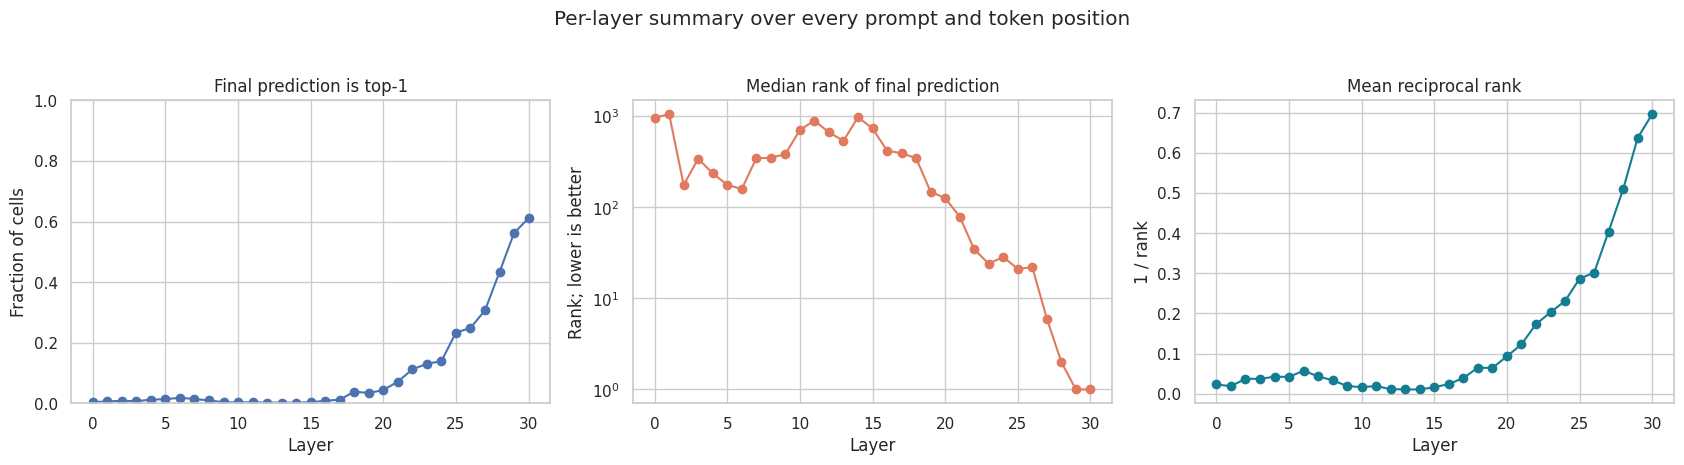

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(17, 4.5))
axes[0].plot(per_layer_summary["layer"], per_layer_summary["top1_final_agreement"], marker="o")
axes[0].set(title="Final prediction is top-1", xlabel="Layer", ylabel="Fraction of cells", ylim=(0, 1))
axes[1].plot(per_layer_summary["layer"], per_layer_summary["median_rank_of_final"], marker="o", color="#e07a5f")
axes[1].set(title="Median rank of final prediction", xlabel="Layer", ylabel="Rank; lower is better", yscale="log")
axes[2].plot(per_layer_summary["layer"], per_layer_summary["mean_reciprocal_rank_final"], marker="o", color="#147d92")
axes[2].set(title="Mean reciprocal rank", xlabel="Layer", ylabel="1 / rank")
fig.suptitle("Per-layer summary over every prompt and token position", y=1.03)
plt.tight_layout()
plt.show()

## 9. Position x layer heatmaps

The per-layer average can hide where the information lives. These heatmaps bin token positions by their relative location in each prompt. The first shows median rank; the second shows the fraction of cells where the final prediction is top-1.

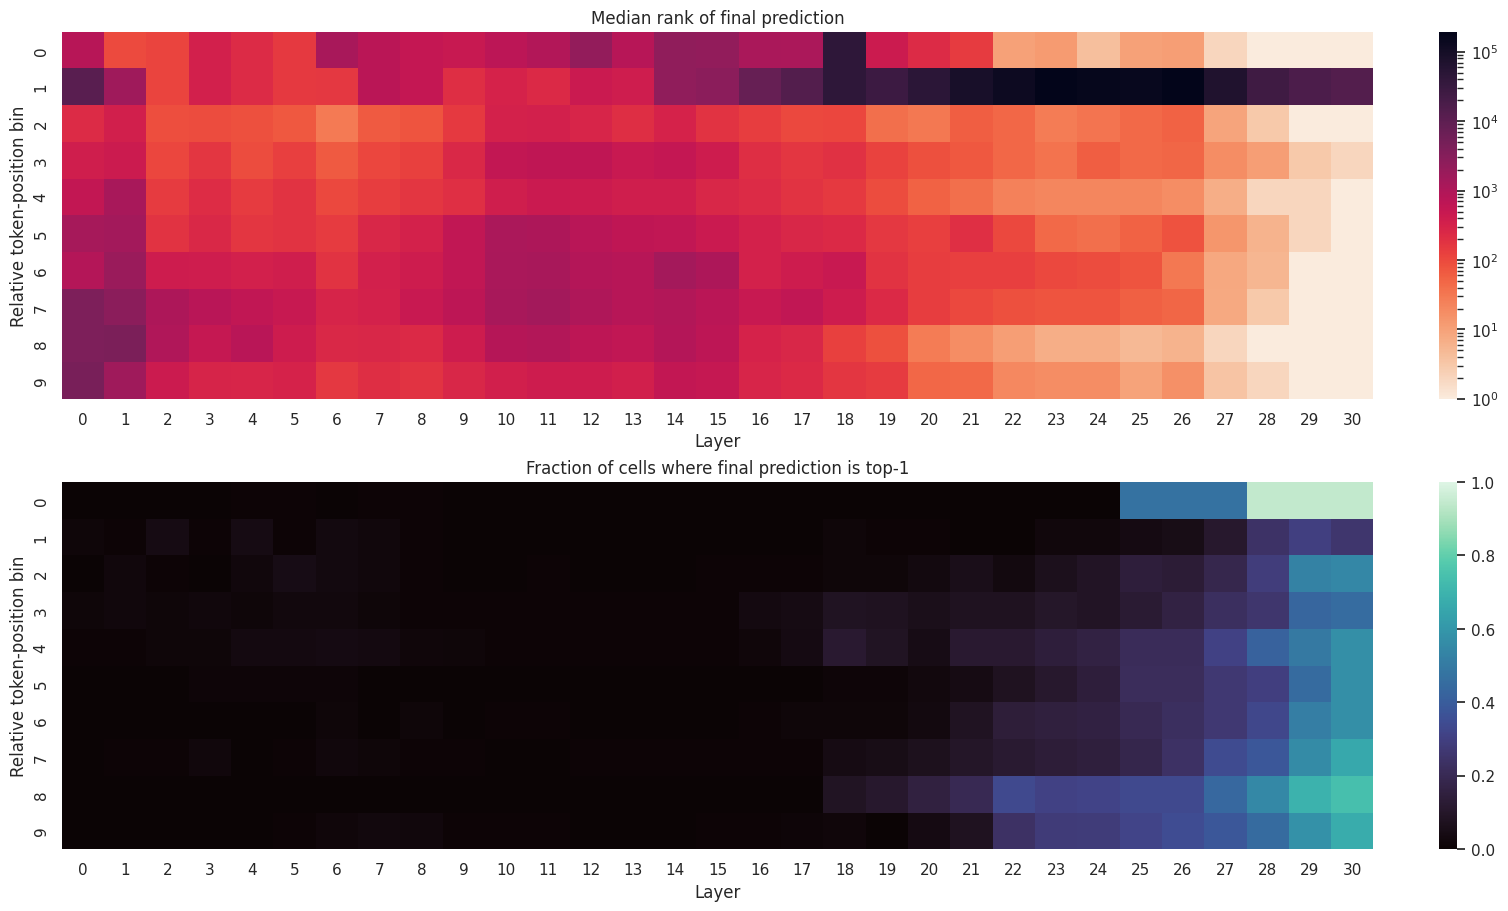

In [12]:
position_df = readout_df.copy()
max_position = position_df.groupby("prompt_index")["position"].transform("max").replace(0, 1)
position_df["relative_position"] = position_df["position"] / max_position
position_df["position_bin"] = pd.cut(position_df["relative_position"], bins=10, labels=False, include_lowest=True)

rank_grid = position_df.pivot_table(index="position_bin", columns="layer", values="rank_of_final_prediction_1_indexed", aggfunc="median")
agreement_grid = position_df.pivot_table(index="position_bin", columns="layer", values="rank_of_final_prediction", aggfunc=lambda x: (x == 0).mean())

fig, axes = plt.subplots(2, 1, figsize=(15, 9), constrained_layout=True)
sns.heatmap(rank_grid, cmap="rocket_r", norm=plt.matplotlib.colors.LogNorm(vmin=1, vmax=max(2, np.nanmax(rank_grid.values))), ax=axes[0])
axes[0].set(title="Median rank of final prediction", xlabel="Layer", ylabel="Relative token-position bin")
sns.heatmap(agreement_grid, cmap="mako", vmin=0, vmax=1, ax=axes[1])
axes[1].set(title="Fraction of cells where final prediction is top-1", xlabel="Layer", ylabel="Relative token-position bin")
plt.show()

## 10. Multi-prompt Jacobian Lens versus Logit Lens comparison

The Jacobian Lens transports an intermediate residual into the final-layer basis. The Logit Lens skips this transport. This section compares them on several feature prompts using the same layers and position. Solid lines are Jacobian Lens; dashed lines are Logit Lens.

,prompt,lens,layer,answer_probability,top_token,answer_rank
0,capital,Jacobian Lens,0,0.000950,•,29
1,capital,Jacobian Lens,1,0.000148,``,72
2,capital,Jacobian Lens,2,0.000980,France,50
3,capital,Jacobian Lens,3,0.000444,"\""",24
4,capital,Jacobian Lens,4,0.000090,"\""",40


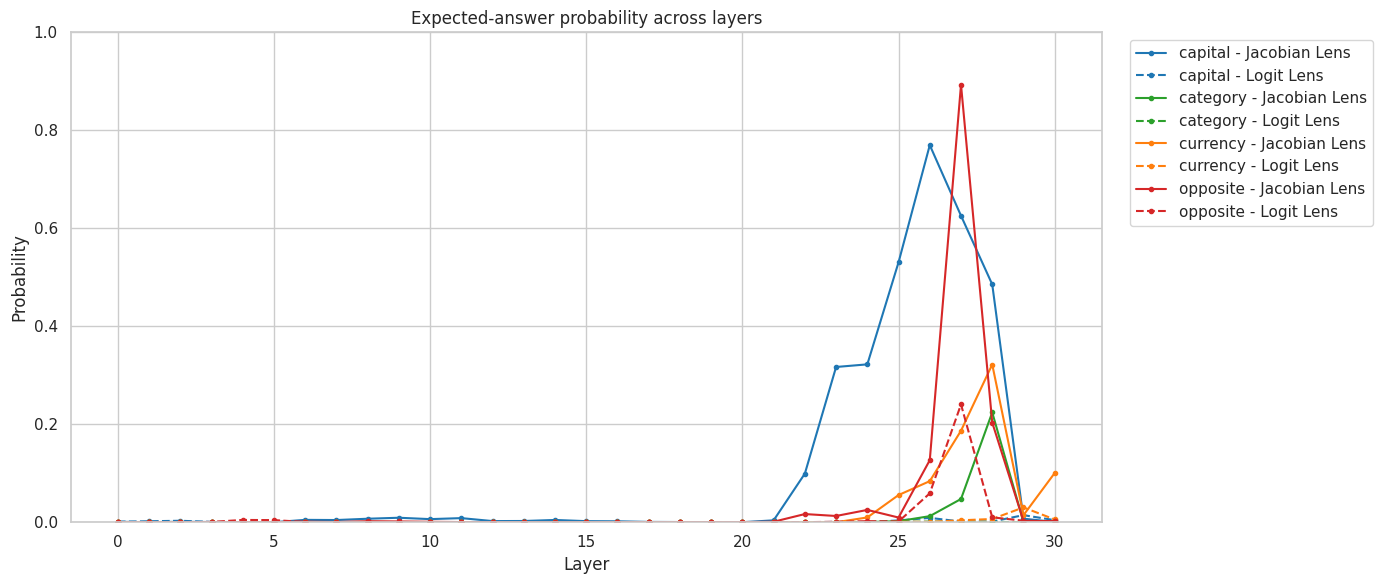

In [13]:
comparison_rows = []
comparison_prompts = [
    ("capital", "The capital of France is", " Paris"),
    ("currency", "The currency used in Japan is the", " yen"),
    ("category", "A dog is a type of", " animal"),
    ("opposite", "The opposite of hot is", " cold"),
]

for prompt_name, prompt_text, answer in comparison_prompts:
    answer_id = one_token_id(answer)
    j_out, _, _ = lens.apply(model, prompt_text, layers=layers, positions=[-2], use_jacobian=True)
    ll_out, _, _ = lens.apply(model, prompt_text, layers=layers, positions=[-2], use_jacobian=False)
    for lens_name, output in [("Jacobian Lens", j_out), ("Logit Lens", ll_out)]:
        for layer in layers:
            logits = output[layer][0]
            comparison_rows.append({
                "prompt": prompt_name,
                "lens": lens_name,
                "layer": layer,
                "answer_probability": float(logits.softmax(dim=-1)[answer_id]),
                "top_token": tokenizer.decode([int(logits.argmax())]),
                "answer_rank": int(rank_targets(logits.unsqueeze(0), torch.tensor([answer_id]))[0]) + 1,
            })

comparison_df = pd.DataFrame(comparison_rows)
display(comparison_df.head())

fig, ax = plt.subplots(figsize=(14, 6))
colors = dict(zip([name for name, _, _ in comparison_prompts], plt.cm.tab10.colors))
for (prompt_name, lens_name), group in comparison_df.groupby(["prompt", "lens"]):
    ax.plot(
        group["layer"],
        group["answer_probability"],
        color=colors[prompt_name],
        linestyle="-" if lens_name == "Jacobian Lens" else "--",
        marker="o",
        markersize=3,
        label=f"{prompt_name} - {lens_name}",
    )
ax.set(title="Expected-answer probability across layers", xlabel="Layer", ylabel="Probability", ylim=(0, 1))
ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

## 11. Category breakdown and prompt-level uncertainty

A global average may be dominated by one relation type. We therefore aggregate by the prompt categories supplied in `probe-swap.json`. The bootstrap below resamples prompts, not individual cells, because positions from one prompt are correlated.

In [14]:
category_summary = (
    readout_df.groupby("category")
    .agg(
        prompts=("prompt_index", "nunique"),
        cells=("layer", "size"),
        top1_final_agreement=("rank_of_final_prediction", lambda x: (x == 1).mean()),
        median_rank=("rank_of_final_prediction", "median"),
        mean_rank=("rank_of_final_prediction", "mean"),
    )
    .sort_values("top1_final_agreement", ascending=False)
)
display(category_summary.style.format({"top1_final_agreement": "{:.1%}", "median_rank": "{:.0f}", "mean_rank": "{:.1f}"}))

def prompt_bootstrap(frame, layer, repetitions=500, seed=0):
    rng = np.random.default_rng(seed)
    per_prompt = frame[frame["layer"] == layer].groupby("prompt_index")["rank_of_final_prediction"].apply(lambda ranks: (ranks == 1).mean()).to_numpy()
    draws = rng.choice(per_prompt, size=(repetitions, len(per_prompt)), replace=True).mean(axis=1)
    return float(per_prompt.mean()), float(np.quantile(draws, 0.025)), float(np.quantile(draws, 0.975))

interval_rows = []
for layer in [layers[0], layers[len(layers)//2], layers[-1]]:
    mean, low, high = prompt_bootstrap(readout_df, layer)
    interval_rows.append({"layer": layer, "mean": mean, "low": low, "high": high})
interval_df = pd.DataFrame(interval_rows)
display(interval_df.style.format({"mean": "{:.1%}", "low": "{:.1%}", "high": "{:.1%}"}))

,prompts,cells,top1_final_agreement,median_rank,mean_rank
category,,,,,
animal-nose,1,620,4.4%,171,3253.5
element-state,5,2883,4.3%,125,5353.5
instr-played,2,1519,3.3%,140,6379.7
holiday-month,1,589,3.2%,134,6178.9
fruit-grows,1,589,3.2%,209,5267.9
sport-equip,1,589,3.1%,95,9484.6
beverage-source,1,496,3.0%,168,6706.2
animal-cover,1,744,2.8%,188,3342.8
season-next,1,496,2.8%,108,3245.5


,layer,mean,low,high
0,0,0.0%,0.0%,0.1%
1,15,0.5%,0.2%,0.8%
2,30,10.3%,8.8%,11.9%


## 12. Jacobian geometry

Each `J_l` is a matrix that transports a residual from layer `l` into the final-layer basis. We inspect its norm and distance from the identity as properties of the measurement instrument. These values do not identify a semantic feature by themselves.

,layer,frobenius_norm,distance_from_identity,cosine_to_identity
0,0,102.368698,110.053505,0.089411
1,1,81.402100,91.958870,0.088448
2,2,70.921738,82.795372,0.102196
3,3,59.289856,73.063545,0.122449
4,4,57.044064,71.136627,0.130115
5,5,56.038200,70.003296,0.140575
6,6,38.522438,58.404957,0.161654
7,7,40.298038,58.838112,0.176494
8,8,42.535370,59.516281,0.191714
9,9,45.134747,60.356915,0.208577


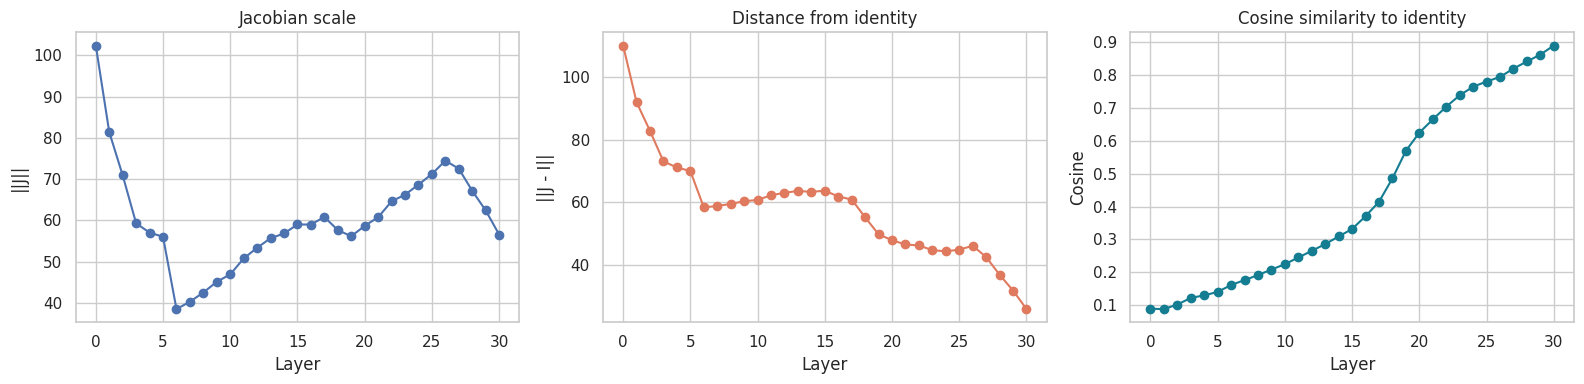

In [15]:
geometry_rows = []
for layer in layers:
    matrix = lens.jacobians[layer].detach().float().cpu()
    identity = torch.eye(matrix.shape[0])
    geometry_rows.append({
        "layer": layer,
        "frobenius_norm": float(matrix.norm()),
        "distance_from_identity": float((matrix - identity).norm()),
        "cosine_to_identity": float(torch.nn.functional.cosine_similarity(matrix.flatten(), identity.flatten(), dim=0)),
    })
geometry_df = pd.DataFrame(geometry_rows)
display(geometry_df)

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
axes[0].plot(geometry_df["layer"], geometry_df["frobenius_norm"], marker="o")
axes[0].set(title="Jacobian scale", xlabel="Layer", ylabel="||J||")
axes[1].plot(geometry_df["layer"], geometry_df["distance_from_identity"], marker="o", color="#e07a5f")
axes[1].set(title="Distance from identity", xlabel="Layer", ylabel="||J - I||")
axes[2].plot(geometry_df["layer"], geometry_df["cosine_to_identity"], marker="o", color="#147d92")
axes[2].set(title="Cosine similarity to identity", xlabel="Layer", ylabel="Cosine")
plt.tight_layout()
plt.show()

## 13. Save the evidence bundle

This keeps the expensive extraction separate from later plotting. If a plotting cell fails, we can reload the CSV instead of recomputing all prompts.

In [16]:
OUTPUT_DIR = Path("week1_assignment_outputs")
OUTPUT_DIR.mkdir(exist_ok=True)
readout_df.to_csv(OUTPUT_DIR / "probe_swap_readouts.csv", index=False)
per_layer_summary.to_csv(OUTPUT_DIR / "per_layer_summary.csv", index=False)
category_summary.to_csv(OUTPUT_DIR / "category_summary.csv")
geometry_df.to_csv(OUTPUT_DIR / "jacobian_geometry.csv", index=False)
metadata = {
    "model": MODEL_NAME,
    "lens_repo": LENS_REPO,
    "lens_revision": LENS_REVISION,
    "lens_file": LENS_FILE,
    "lens_source_layers": layers,
    "lens_n_prompts": lens.n_prompts,
    "probe_prompts_run": len(items_to_run),
    "max_seq_len": MAX_SEQ_LEN,
    "rank_convention": "1-indexed; rank 1 is top-ranked",
}
(OUTPUT_DIR / "metadata.json").write_text(json.dumps(metadata, indent=2))
print(f"Saved evidence bundle to {OUTPUT_DIR.resolve()}")

Saved evidence bundle to /content/jacobian-lens/week1_assignment_outputs


## 14. Final interpretation checklist

- [ ] Qwen3.6-27B and its matching pre-fitted lens were loaded, or the fallback was clearly documented.
- [ ] Representative prompts covered factual, multi-hop, latent-topic, arithmetic, structural, code, and safety-relevant examples.
- [ ] A full slice grid rendered with all positions and layers.
- [ ] Experiment prompts came from `data/experiments/`.
- [ ] `lens.apply(..., positions=None)` was used for every valid source position.
- [ ] The extracted table contains one row per prompt x position x layer.
- [ ] The per-layer summary aggregates over all prompts and positions.
- [ ] Results were checked by category and prompt-level uncertainty.
- [ ] J-lens and logit-lens comparisons use the same prompts, positions, and layers.
- [ ] Readout, behavior, and causal claims were not conflated.

### Questions for the presentation

1. Which feature family became readable earliest?
2. Did the Jacobian Lens improve intermediate readability relative to the Logit Lens?
3. Were the patterns consistent across prompt categories?
4. Which token positions were most informative?
5. What evidence would still be needed for a causal claim about a feature?